               日時 |  RSSI(HEX) |  RSSI(DEC) |      SensorType      | Volt  | BLE
-------------------------------------------------------------------------------------
Data frame has 222562 records


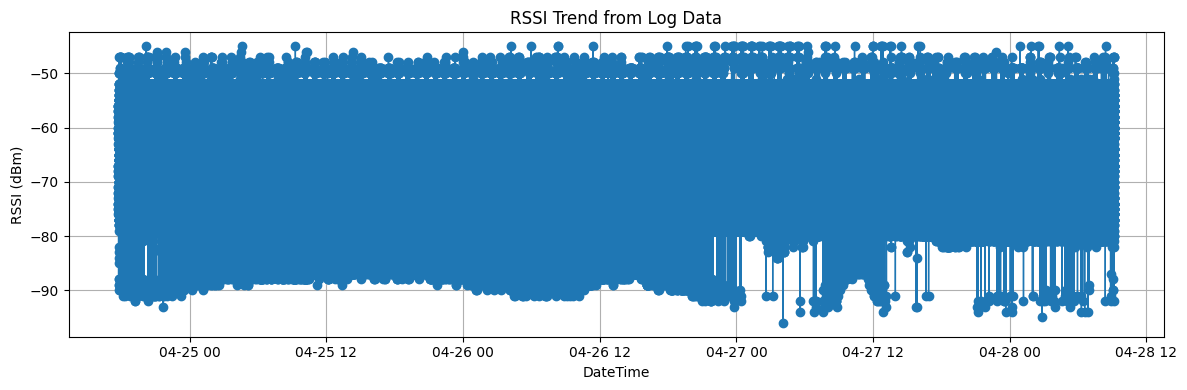

In [4]:
# ======================================================
# Need to install Python version higher than 3.10
# ======================================================
from pathlib import Path
import matplotlib.pyplot as plt
from datetime import datetime
from dataclasses import dataclass
from typing import ClassVar, Optional
from typing import Union
import re
import pandas as pd

# =====================================================================
# センサ種別毎のクラス変数定義：データは1byteが0x00でダンプ形式になっている
# =====================================================================
@dataclass
class HumanSensor:
    prefix: str   # 10byte
    MFGcode: str  # 4byte
    Beacon: str   # 4byte
    Battery: str  # 4 byte
    EventStatus: str # 2byte
    Reserve: str  # 8Byte
    User: str     # 4byte 
    SubType: str  # 2byte
    Reserve2: str # 3byte
        
    # 固定値定義
    SENSOR_PREFIX: ClassVar[str] = "02010612FF"
    SENSOR_BEACON: ClassVar[str] = "82BC"
    
    def __post_init__(self):
        if len(self.prefix) != 10:
            raise ValueError("prefix must have 10 characters")

@dataclass
class DistanceSensor:
    prefix: str   # 10byte
    MFGcode: str  # 4byte
    Beacon: str   # 4byte
    Battery: str  # 4byte
    EventStatus: str  # 2Byte
    Reserve: str  # 4Byte
    Distance: str # 4Byte 
    User: str     # 4Byte 
    SubType: str  # 2Byte
    Reserve2: str # 3byte
        
    # 固定値定義
    SENSOR_PREFIX: ClassVar[str] = "02010612FF"
    SENSOR_BEACON: ClassVar[str] = "83BC"
    
    def __post_init__(self):
        if len(self.prefix) != 10:
            raise ValueError("prefix must have 10 characters")
            
@dataclass
class EnvironmentSensor:
    prefix: str     # 10byte
    localname: str  # 8byte
    identifies: str # 8byte
    flag: str       # 2byte
    counter: str    # 2byte
    pressure: str   # 8byte
    temperature: str # 8byte
    humidity: str    # 8byte
    Battery: str     # 4byte
    illuminance_indx: str # 1byte
    illuminance_data: str # 3byte

    # 固定値定義
    SENSOR_PREFIX: ClassVar[str] = "0201040509"
    SENSOR_LOCALNAME: ClassVar[str] = "L072"
    SENSOR_LOCALNAME2: ClassVar[str] = "L073"

    def __post_init__(self):
        if len(self.prefix) != 10:
            raise ValueError("prefix must have 10 characters")

@dataclass
class Co2Sensor:
    prefix: str     # 10byte
    localname: str  # 8byte
    identifies: str # 8byte
    flag: str       # 2byte
    counter: str    # 2byte
    Co2: str        # 4byte

    # 固定値定義
    SENSOR_PREFIX: ClassVar[str] = "0201040509"
    SENSOR_LOCALNAME: ClassVar[str] = "J816"
    SENSOR_LOCALNAME2: ClassVar[str] = "J817"

    def __post_init__(self):
        if len(self.prefix) != 10:
            raise ValueError("prefix must have 10 characters")

@dataclass
class AcccelerateSensor:
    prefix: str     # 10byte
    localname: str  # 4byte
    identifies: str # 4byte
    serial: str     # 12byte
    reserve: str    # 2byte
    X: str          # 2byte
    Y: str          # 2byte
    Z: str          # 2byte
    temperature: str    # 2byte
    noused: str     # 18byte
    Battery: str    # 4byte

    # 固定値定義
    SENSOR_PREFIX: ClassVar[str] = "0201061BFF"
    SENSOR_LOCALNAME: ClassVar[str] = "CE01"

    def __post_init__(self):
        if len(self.prefix) != 10:
            raise ValueError("prefix must have 10 characters")
            
# センサクラス変数の型エイリアス
SensorData = Union[
    HumanSensor,
    DistanceSensor,
    EnvironmentSensor,
    Co2Sensor,
    AcccelerateSensor,
    None
]
            
# =============================
# センサ種別判定関数：36Byte目
# =============================
def identify_sensor(data: str) -> str:

    prefix = data[0:10]
    beacon = data[14:18]
    localname_hex = data[10:18]
    
    try:
        localname = bytes.fromhex(localname_hex).decode("ascii")
    except Exception:
        localname = f"(ascii_decode_error:{localname_hex})"
        #return localname

    if prefix == HumanSensor.SENSOR_PREFIX and beacon == HumanSensor.SENSOR_BEACON:
        return "HumanSensor"
    elif prefix == DistanceSensor.SENSOR_PREFIX and beacon == DistanceSensor.SENSOR_BEACON:
        return "DistanceSensor"
    elif prefix == EnvironmentSensor.SENSOR_PREFIX and localname in (EnvironmentSensor.SENSOR_LOCALNAME, EnvironmentSensor.SENSOR_LOCALNAME2):
        return "EnvironmentSensor"
    elif prefix == Co2Sensor.SENSOR_PREFIX and localname in (Co2Sensor.SENSOR_LOCALNAME, Co2Sensor.SENSOR_LOCALNAME2):
        return "Co2Sensor"
    elif prefix == AcccelerateSensor.SENSOR_PREFIX:
        return "AcccelerateSensor"
    else:
        return f"Unknown_Sensor:{prefix}"
        #return prefix
    
# =============================
# センサデータ抽出関数：
# =============================
def extract_sensor_data(handle: str, data: str) -> SensorData:
    match handle:
        case 'HumanSensor':
            sn_data = HumanSensor(prefix=data[0:10], 
                                  MFGcode=data[10:14], 
                                  Beacon=data[14:18], 
                                  Battery=data[18:22],
                                  EventStatus=data[22:24],
                                  Reserve=data[24:32],
                                  User=data[32:36],
                                  SubType=data[36:38],
                                  Reserve2=data[38:41])
            # 00は動きなし，04が動き検出
            sn_data.EventStatus = int(sn_data.EventStatus)
            # センサ識別子
            sn_data.User = parse_le16(sn_data.User)
            # 電池残量の単位はV
            Battery = parse_le16(sn_data.Battery)
            sn_data.Battery = round(Battery/100,2)
        case 'DistanceSensor':
            sn_data = DistanceSensor(prefix=data[0:10],
                                     MFGcode=data[10:14],
                                     Beacon=data[14:18],
                                     Battery=data[18:22],
                                     EventStatus=data[22:24],
                                     Reserve=data[24:28],
                                     Distance=data[28:32],
                                     User=data[32:36],
                                     SubType=data[36:38],
                                     Reserve2=data[38:41])
            # 距離の単位はmm
            sn_data.Distance = parse_le16(sn_data.Distance)
            # センサ識別子
            sn_data.User = parse_le16(sn_data.User)
            # 電池残量の単位はV
            Battery = parse_le16(sn_data.Battery)
            sn_data.Battery = round(Battery/100,2)
        case 'EnvironmentSensor':
            sn_data = EnvironmentSensor(prefix=data[0:10],
                                      localname=data[10:18],
                                      identifies=data[18:26],
                                      flag=data[26:28],
                                      counter=data[28:30],
                                      pressure=data[30:38],
                                      temperature=data[38:46],
                                      humidity=data[46:54],
                                      Battery=data[54:58],
                                      illuminance_indx=data[58:59],
                                      illuminance_data=data[59:62])
            # センサ識別子
            sn_data.localname = bytes.fromhex(sn_data.localname).decode("ascii")
            # 気圧の単位はhpa
            Pressure = parse_le16(sn_data.pressure)
            sn_data.pressure = Pressure / 100
            # 温度の単位は℃
            Temperature = parse_le16(sn_data.temperature)
            sn_data.temperature = Temperature / 100
            # 湿度の単位は％
            Humidity = parse_le16(sn_data.humidity)
            sn_data.humidity = Humidity / 1024
            # 照度の単位はlx
            Index = int(sn_data.illuminance_indx)
            Illuminance = int(sn_data.illuminance_data, 16)
            Illuminance = pow(2, Index) * 0.01 * Illuminance
            if Illuminance < 350:
                sn_data.illuminance = Illuminance * 2.1242
            elif Illuminance >= 350:
                sn_data.illuminance = Illuminance * 1.0692 + 388.24
            else:
                sn_data.illuminance = "N/A"
            # 電池残量の単位はV
            Battery = parse_le16(sn_data.Battery)
            sn_data.Battery = round((Battery*(2.03/65535))*3,2) 
        case 'Co2Sensor':
            sn_data = Co2Sensor(prefix=data[0:10], 
                                localname=data[10:18],
                                identifies=data[18:26],
                                flag=data[26:28],
                                counter=data[28:30],
                                Co2=data[30:34])
            # センサ識別子
            sn_data.localname = bytes.fromhex(sn_data.localname).decode("ascii")
            # Co2濃度
            sn_data.Co2 = int(sn_data.Co2, 16)
        case 'AcccelerateSensor':
            sn_data = AcccelerateSensor(prefix=data[0:10], 
                                        localname=data[10:14],
                                        identifies=data[14:18],
                                        serial=data[18:30],
                                        reserve=data[30:32],
                                        X=data[32:34],
                                        Y=data[34:36],
                                        Z=data[36:38],
                                        temperature=data[38:40],
                                        noused=data[40:58],
                                        Battery=data[58:62])
            # センサ識別子（シリアル番号）
            #sn_data.serial = parse_le16(sn_data.serial)
            sn_data.serial = sn_data.serial
            # 加速度の単位はG
            sn_data.X = round(int(sn_data.X, 16) / 64, 2)
            sn_data.Y = round(int(sn_data.Y, 16) / 64, 2)
            sn_data.Z = round(int(sn_data.Z, 16) / 64, 2)
            # 温度（singed charで25℃からの相対値：2の補数として扱う）
            raw = int(sn_data.temperature, 16)
            sn_data.temperature = 25 + (raw - 256 if raw >= 128 else raw)
            # 電池残量の単位はV
            Battery = parse_le16(sn_data.Battery)
            sn_data.Battery = round(Battery/1000,2)
        case _:
            return None
        
    return sn_data

# =======================================
# リトルエンディアンからビッグエンディアン：
# =======================================
def parse_le16(hexstr: str) -> int:
    return int.from_bytes(bytes.fromhex(hexstr)[::-1], byteorder="big")

# =======================================
# 各センサの変数の値を辞書型リスト化：
# =======================================
def set_sensordata2pdframe(sn_type: str, sn_data: SensorData, dt_str: str, pd_values: list):
    match sn_type:
        case 'HumanSensor':
            pd_values.append({
                'Timestamp': dt_str,
                'Prefix': sn_data.prefix,
                'Beacon': sn_data.Beacon,
                'EventStatus': sn_data.EventStatus,
                'Battery' : sn_data.Battery,
                'User': sn_data.User
            })
        case 'DistanceSensor':
            pd_values.append({
                'Timestamp': dt_str,
                'Prefix': sn_data.prefix,
                'Beacon': sn_data.Beacon,
                'Distance': sn_data.Distance,
                'Battery' : sn_data.Battery,
                'User': sn_data.User
            })
        case 'EnvironmentSensor':
            pd_values.append({
                'Timestamp': dt_str,
                'Prefix': sn_data.prefix,
                'Localname': sn_data.localname,
                'Pressure': sn_data.pressure,
                'Temperature': sn_data.temperature,
                'Humidity': sn_data.humidity,
                'Illuminance': sn_data.illuminance,
                'Battery' : sn_data.Battery
            })
        case 'Co2Sensor':
            pd_values.append({
                'Timestamp': dt_str,
                'Prefix': sn_data.prefix,
                'Localname': sn_data.localname,
                'Co2': sn_data.Co2
            })
        case 'AcccelerateSensor':
            pd_values.append({
                'Timestamp': dt_str,
                'Prefix': sn_data.prefix,
                'Localname': sn_data.localname,
                'Serial': sn_data.serial,
                'X': sn_data.X,
                'Y': sn_data.Y,
                'Z': sn_data.Z,
                'Temperature': sn_data.temperature,
                'Battery' : sn_data.Battery
            })
        case None:
            return
    return

#log_file_path = 'D:/rerf/coresearch/RSSI/WiFi_Capture/20251021/teraterm_251022_oya.log'
#log_file_path = 'D:/rerf/coresearch/RSSI/WiFi_Capture/20251021/teraterm_251021_oya.log'
log_file_path = 'D:/rerf/coresearch/RSSI/WiFi_Capture/20260424/all_log_20260424.log'
#log_file_path = 'D:/rerf/coresearch/RSSI/WiFi_Capture/20260501/all_log_20260501.log'

matching_data = []

with open(log_file_path, "r", encoding="utf-8", errors="ignore") as file:
    lines = file.readlines()

# まず時刻とセンサデータだけを抽出する
for i in range(1, len(lines)):
    line = lines[i]
    if "collect-x:" in line:
        ts_line = lines[i-1]
        ts_match = re.search(r"\[(\d+\.\d+)", ts_line)
        parts = line.split("collect-x:")
        if ts_match and len(parts) > 1:
            timestamp = float(ts_match.group(1))
            data = parts[1].strip()
            if data.startswith("5 0001") or data.startswith("6 0001") or data.startswith("7 0001"):
                # ble_noは個別に保存
                ble_no = data[0:2]
                # ble_noを削除して追加
                cleaned = data[2:].strip()
                matching_data.append((timestamp, cleaned, ble_no))
                    
# 全件RSSIとセンサ種別，センサデータ（電圧のみ）をテキスト表示
print(f"{'日時':>17} | {'RSSI(HEX)':>10} | {'RSSI(DEC)':>10} | {'SensorType' :^20} | {'Volt' :^5} | {'BLE' :^3}")
print("-" * 85)

rssi_values = []
dt_values = []
pd_values = []

for timestamp, entry, ble_no in matching_data:
    if len(entry) >= 24:
        hex_str = entry[22:24]
        try:
            val = int(hex_str, 16)
            if val >= 128:
                val -= 256
            rssi_values.append(val)
            dt_str = datetime.fromtimestamp(timestamp).strftime("%Y/%m/%d %H:%M:%S")
            dt_raw = datetime.fromtimestamp(timestamp)
            dt_values.append(dt_raw)
            sensor_type = identify_sensor(entry[36:])
            if sensor_type in ('HumanSensor', 'DistanceSensor', 'EnvironmentSensor', 'Co2Sensor', 'AcccelerateSensor'):
                sn_data = extract_sensor_data(sensor_type, entry[36:])
            else:
                print(sensor_type)
                continue
            if sn_data != None and sensor_type != 'Co2Sensor':
                Battery = sn_data.Battery
            elif sensor_type == 'Co2Sensor':
                Battery = sn_data.Co2
            else:
                Battery = 'N/A'
            #print(f"{dt_str:>17} | {hex_str:>10} | {val:>10} | {sensor_type:^20} | {Battery:>5} | {ble_no:>3}")
            # 各センサの値をリスト化
            set_sensordata2pdframe(sensor_type, sn_data, dt_str, pd_values)
        except ValueError:
            print(f"{dt_str:>17} | {hex_str:>10} | {val:>10} | {'Invalid Sensor Data':>20}")

# リストからデータフレームに変換する
df_sensor = pd.DataFrame(pd_values)

# フィルターの作成
if 'Localname' in df_sensor.columns:
    mask_localname = df_sensor.duplicated(subset=['Timestamp', 'Localname'], keep='first')
    if 'Serial' in df_sensor.columns:
        mask_serial = df_sensor.duplicated(subset=['Timestamp', 'Serial'], keep='first')
        if 'User' in df_sensor.columns:
            mask_user = df_sensor.duplicated(subset=['Timestamp', 'User'], keep='first')
            combined_mask = mask_localname | mask_serial | mask_user
        else:
            combined_mask = mask_localname | mask_serial
    elif 'User' in df_sensor.columns:
        mask_user = df_sensor.duplicated(subset=['Timestamp', 'User'], keep='first')
        combined_mask = mask_localname | mask_user
    else:
        combined_mask = mask_localname
elif 'Serial' in df_sensor.columns:
    mask_serial = df_sensor.duplicated(subset=['Timestamp', 'Serial'], keep='first')
    if 'User' in df_sensor.columns:
        mask_user = df_sensor.duplicated(subset=['Timestamp', 'User'], keep='first')
        combined_mask = mask_serial | mask_user
    else:
        combined_mask = mask_serial
else:
    mask_user = df_sensor.duplicated(subset=['Timestamp', 'User'], keep='first')
    combined_mask = mask_user
        
# フィルターの適用
df_sensor = df_sensor[~combined_mask]

print(f'Data frame has {len(df_sensor)} records')

#df_sensor.to_excel('D:/rerf/coresearch/RSSI/WiFi_Capture/20260501/all_log_20260501.xlsx')
df_sensor.to_excel('D:/rerf/coresearch/RSSI/WiFi_Capture/20260424/all_log_20260424.xlsx')
            
# RSSIの折れ線グラフ描画
plt.figure(figsize=(12, 4))
plt.plot(dt_values, rssi_values, marker='o', linestyle='-', linewidth=1)
plt.title('RSSI Trend from Log Data')
plt.xlabel('DateTime')
plt.ylabel('RSSI (dBm)')
plt.grid(True)
plt.tight_layout()
plt.show()


⚠ Z: 4347件の外れ値を除去しました。
⚠ Battery: 28901件の外れ値を除去しました。
⚠ Co2: 3件の外れ値を除去しました。


C:\Users\ono\AppData\Local\Temp\ipykernel_21496\591374800.py:39: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_norm.interpolate(method='linear', inplace=True)


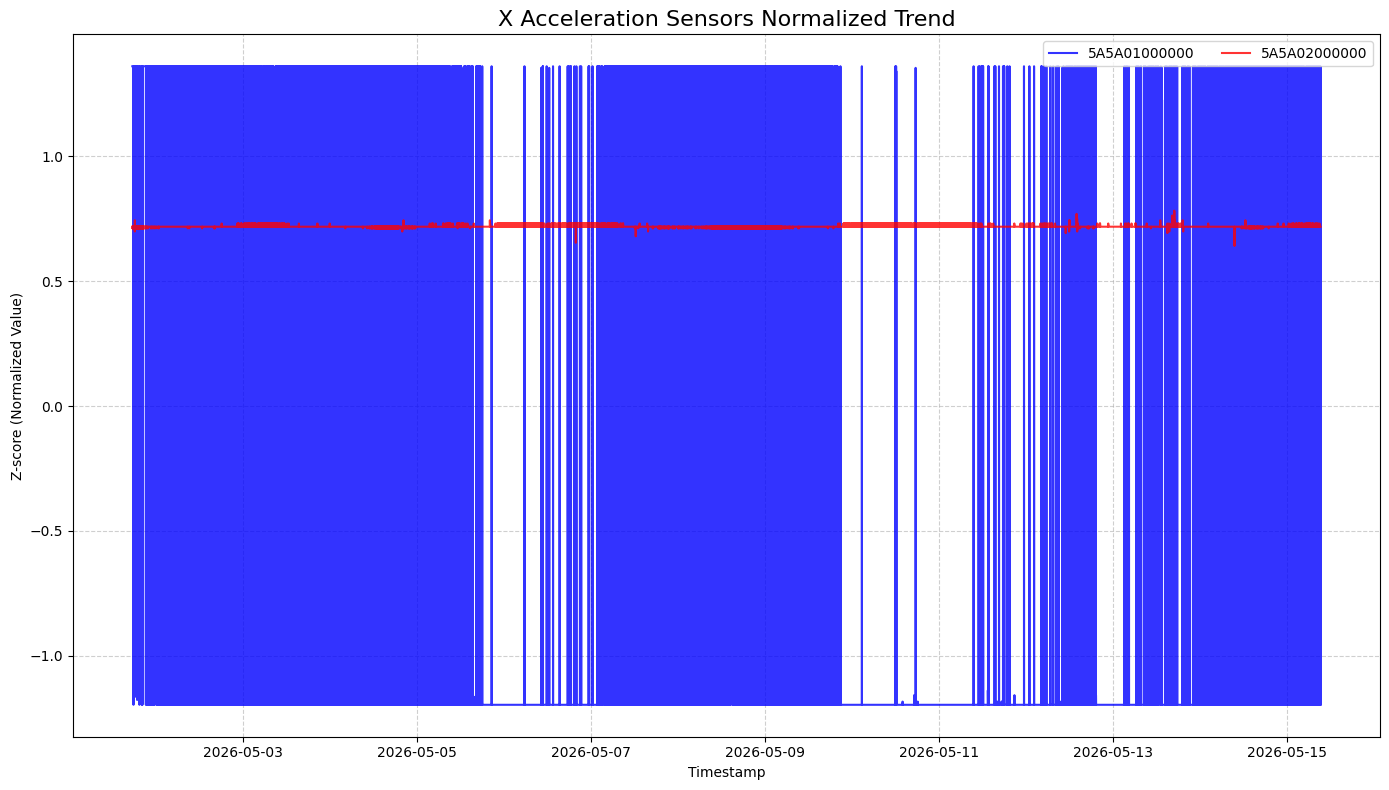

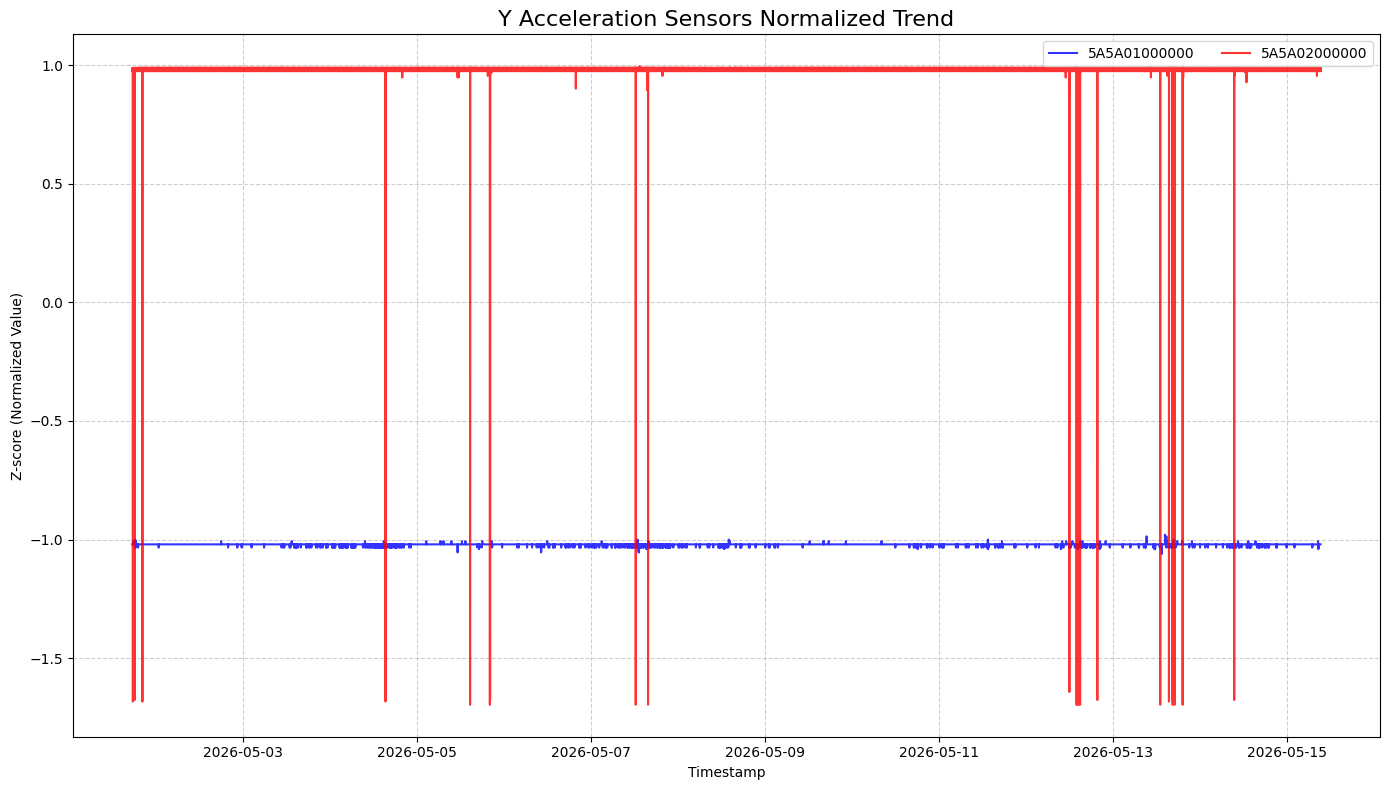

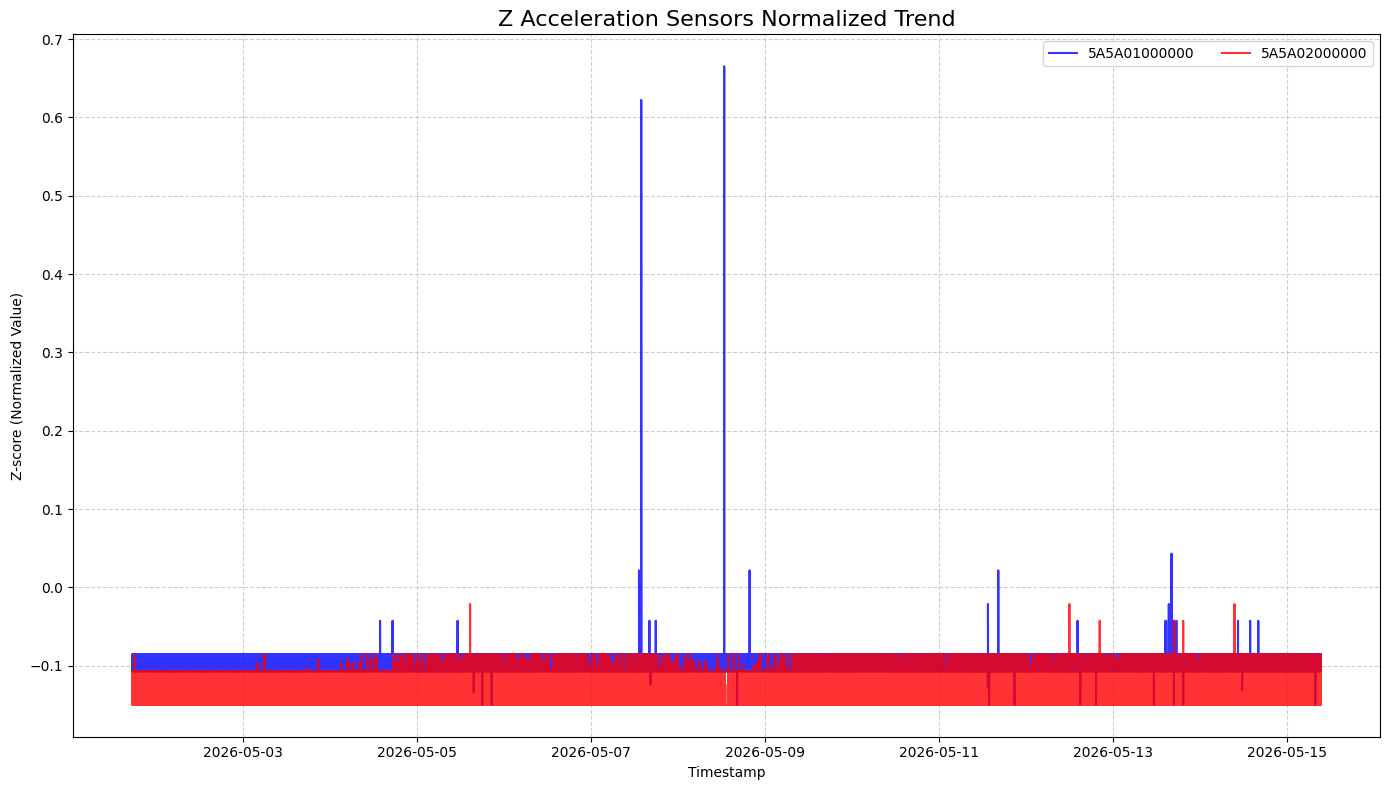

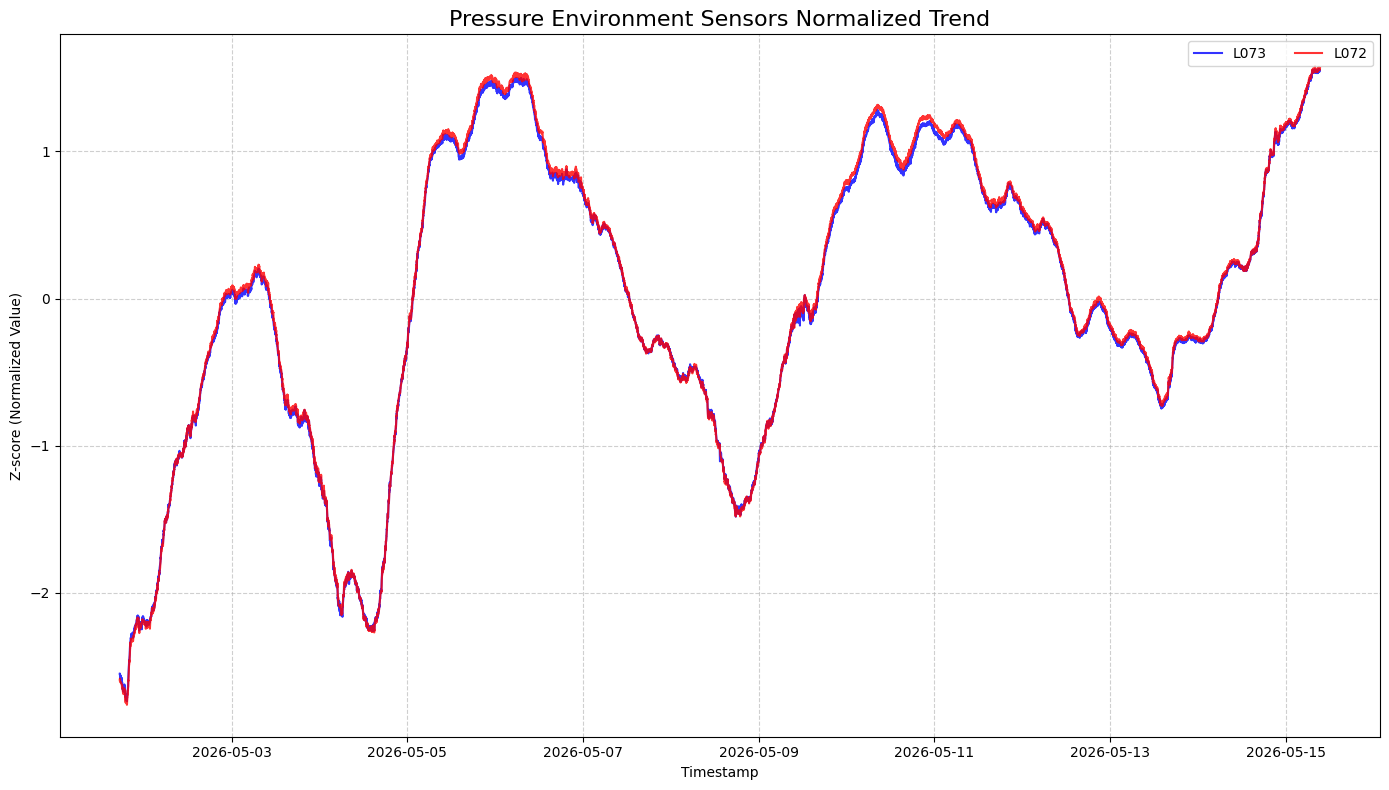

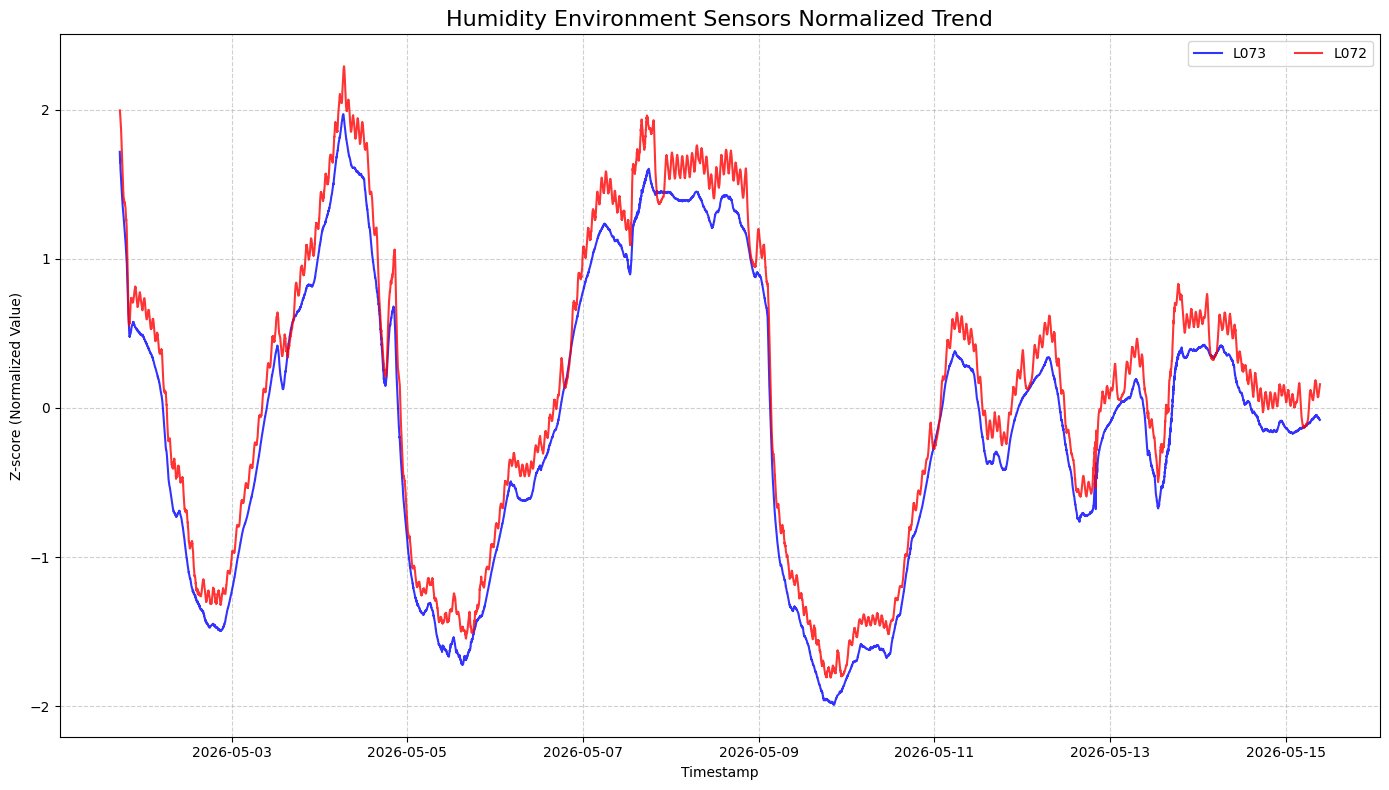

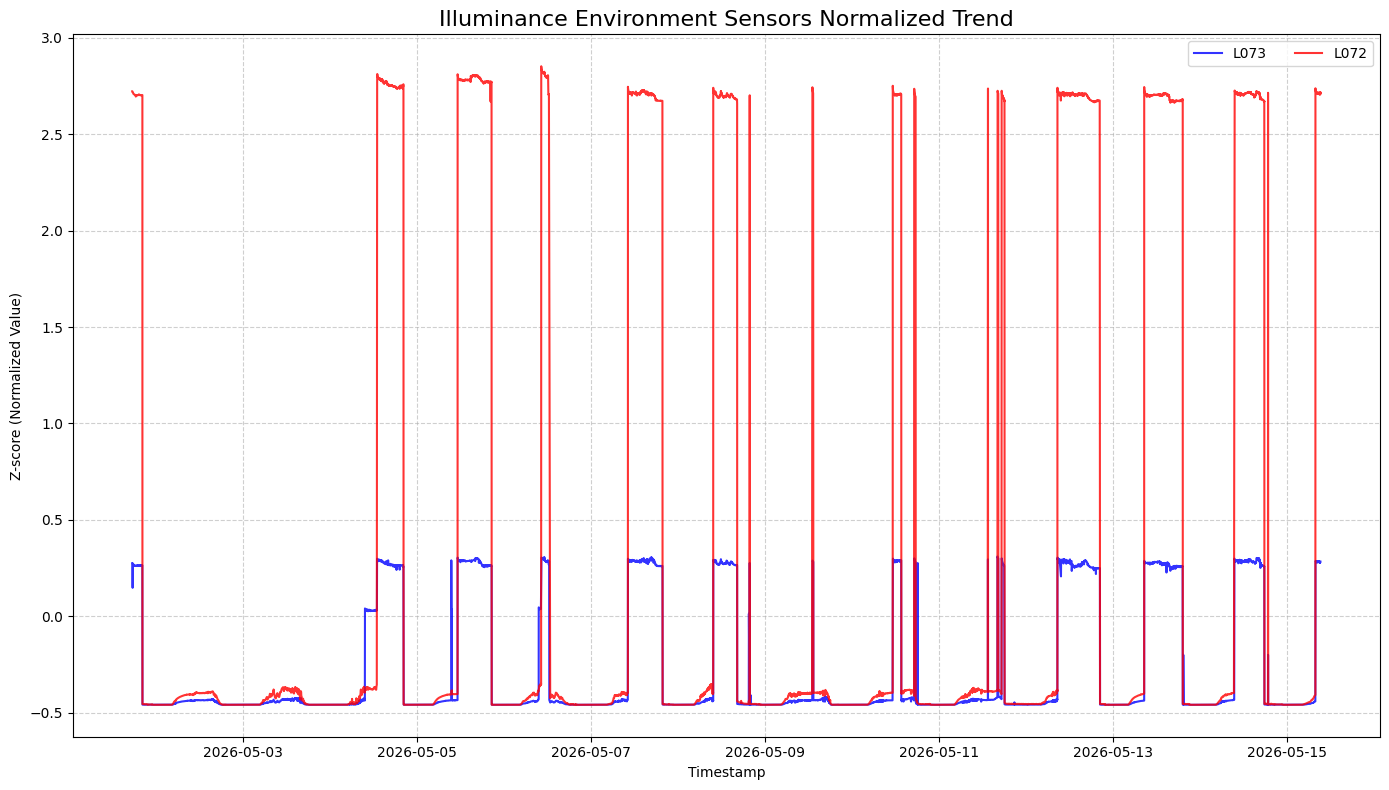

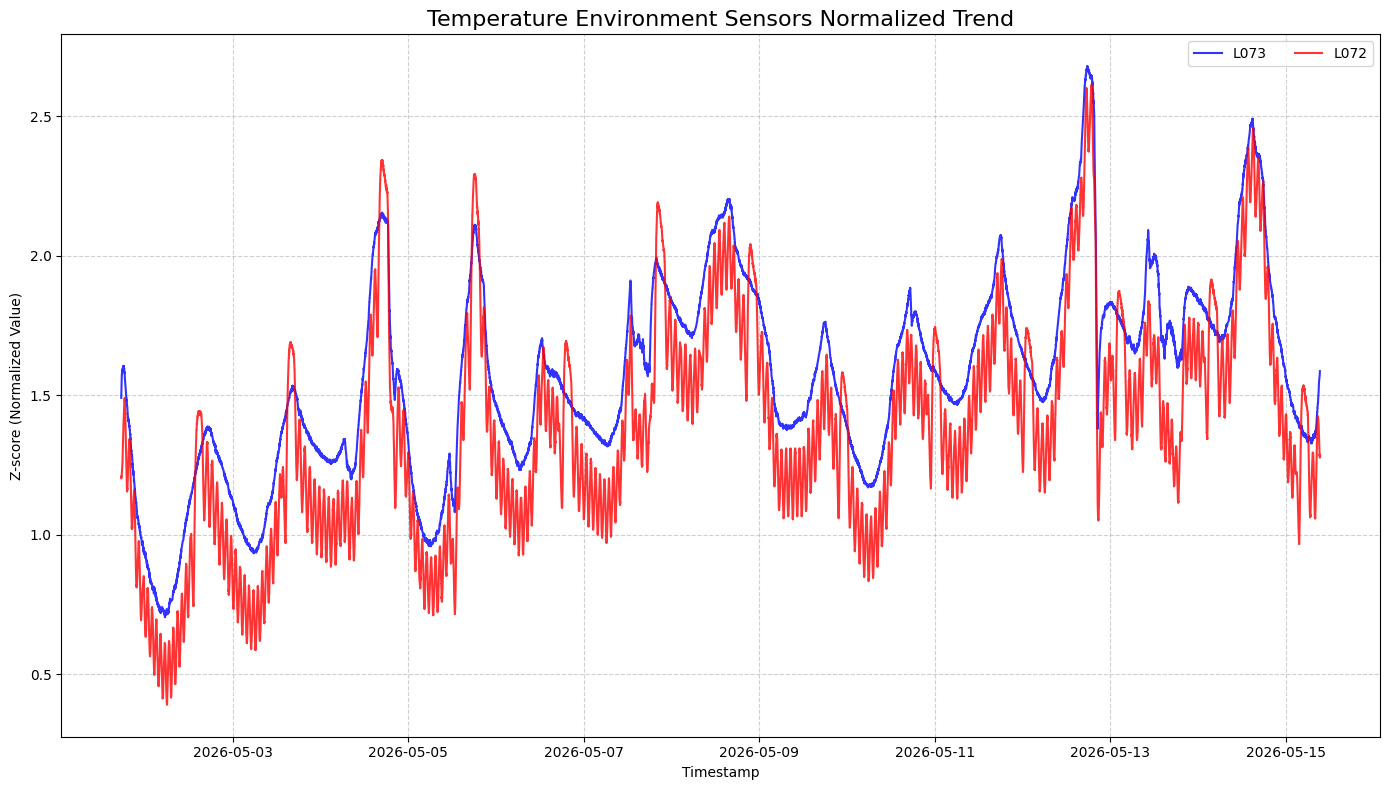

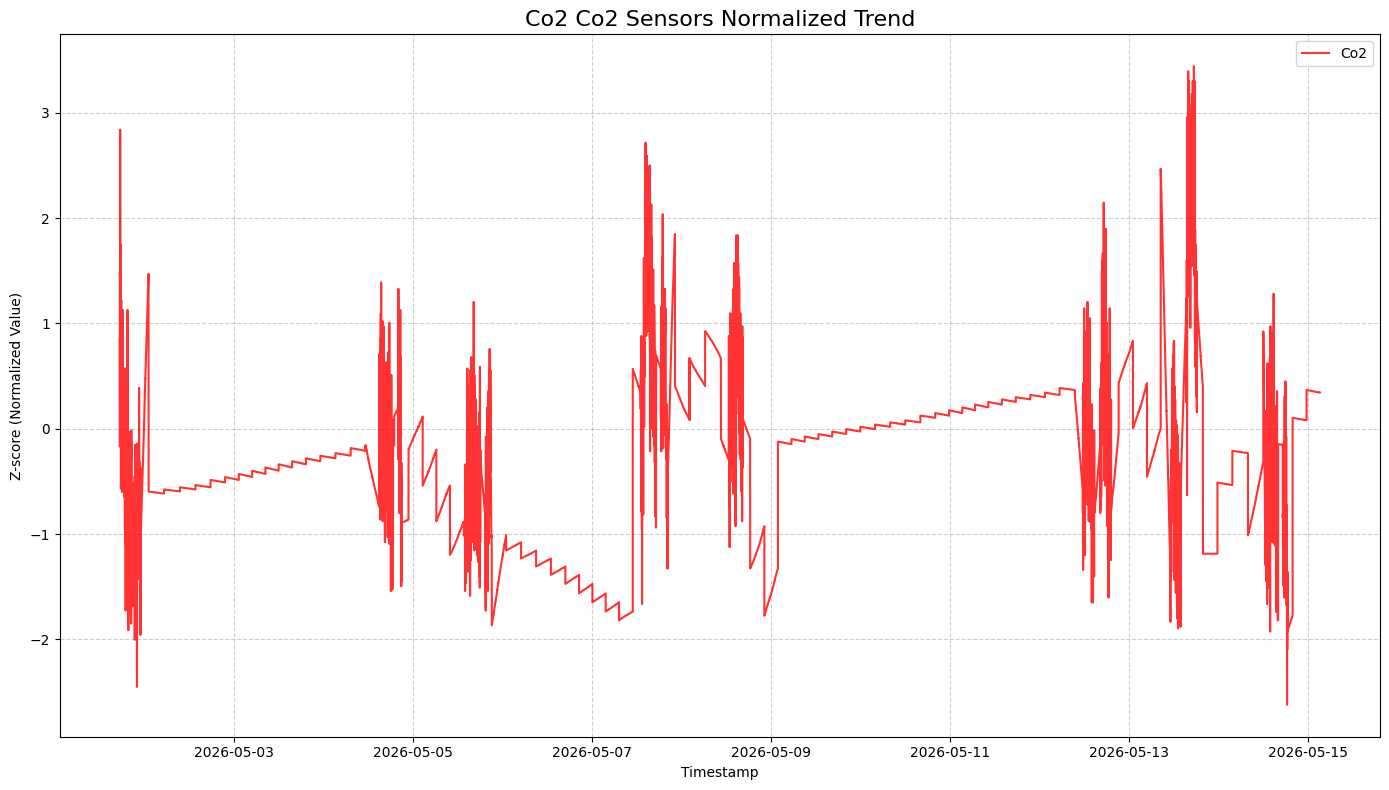

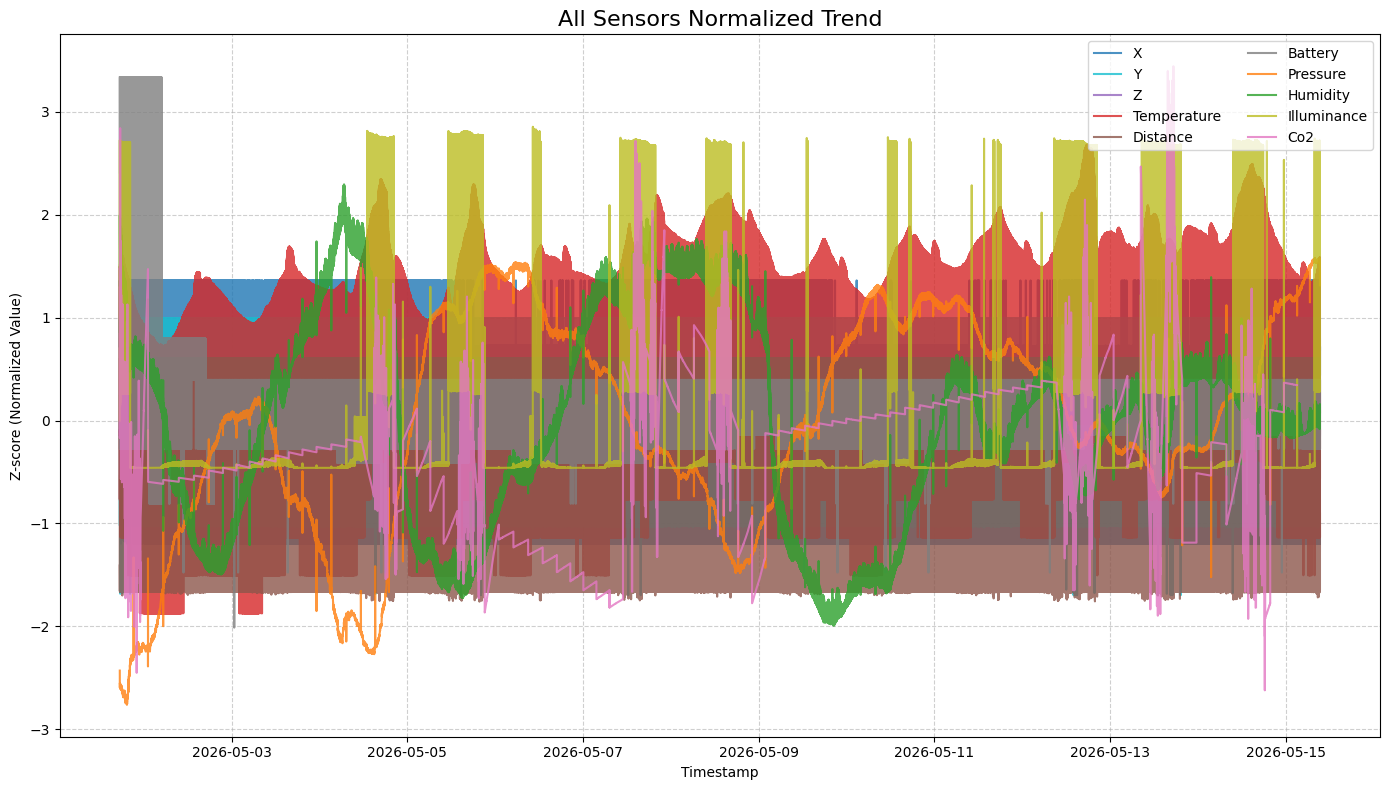

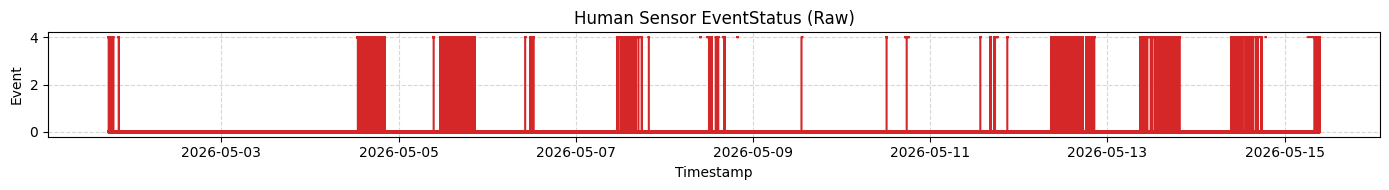

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import numpy as np

# ======================================================
# 1. Excelファイル読み込み
# ======================================================
#filename = "D:/rerf/coresearch/RSSI/WiFi_Capture/20251021/teraterm_251021_oya.xlsx"
#filename = "D:/rerf/coresearch/RSSI/WiFi_Capture/20260424/all_log_20260424.xlsx"
filename = "D:/rerf/coresearch/RSSI/WiFi_Capture/20260501/all_log_20260501.xlsx"
df = pd.read_excel(filename)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# ======================================================
# 2. 数値データの標準化（Zスコア）
# ======================================================
# 対象列を指定（TimestampやID系は除外）
numeric_cols = [
    'X', 'Y', 'Z', 'Temperature', 'Distance',
    'Battery', 'Pressure', 'Humidity', 'Illuminance', 'Co2'
]

# 存在する列のみを抽出（Excelによって欠落列がある場合に備える）
numeric_cols = [c for c in numeric_cols if c in df.columns]

scaler = StandardScaler()
df_norm = df.copy()
df_norm[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# --- 外れ値の検出と除去（Zスコアの絶対値 > 3.5 のものを除く） ---
for col in numeric_cols:
    mask = np.abs(df_norm[col]) > 3.5
    if mask.any():
        print(f"⚠ {col}: {mask.sum()}件の外れ値を除去しました。")
        df_norm.loc[mask, col] = np.nan  # 欠損に置換

# --- 欠損値を前後で補間 ---
df_norm.interpolate(method='linear', inplace=True)

# --- 日付でソート ---
df_norm = df_norm.sort_values('Timestamp')

# ======================================================
# 3. グラフにすべてのトレンドを表示
# ======================================================
# 色分けを定義（カテゴリ別に）
color_map = {
    'X': 'tab:blue',
    'Y': 'tab:cyan',
    'Z': 'tab:purple',
    'Temperature': 'tab:red',
    'Pressure': 'tab:orange',
    'Humidity': 'tab:green',
    'Illuminance': 'tab:olive',
    'Co2': 'tab:pink',
    'Distance': 'tab:brown',
    'Battery': 'tab:gray'
}

def plot_sensor(df_list, labels, colors, columns, title_prefix, overlay=False):
    """
    df_list  : プロットするDataFrameのリスト
    labels   : 凡例ラベルのリスト
    colors   : 線の色のリスト
    columns  : プロットする列名のリスト
    title_prefix: グラフタイトルのプレフィックス
    """
    def _apply_common_style(title):
        plt.title(title, fontsize=16)
        plt.xlabel('Timestamp')
        plt.ylabel('Z-score (Normalized Value)')
        plt.legend(loc='upper right', ncol=2)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

    if overlay:
        # 全列を1グラフに重ねる
        plt.figure(figsize=(14, 8))
        for col, label, color in zip(columns, labels, colors):
            plt.plot(df_list['Timestamp'], df_list[col],
                     label=label, color=color, alpha=0.8)
        _apply_common_style(f'{title_prefix} Normalized Trend')
    else:
        # センシング項目ごとに1グラフ
        for col in columns:
            plt.figure(figsize=(14, 8))
            for df, label, color in zip(df_list, labels, colors):
                plt.plot(df['Timestamp'], df[col],
                         label=label, color=color, alpha=0.8)
            _apply_common_style(f'{col} {title_prefix} Normalized Trend')

#--- 加速度センサのグラフ ---
df_accel = df_norm[['Timestamp','Serial','X','Y','Z']]
plot_sensor(
    df_list  = [df_accel[df_accel['Serial'] == '5A5A01000000'],
                df_accel[df_accel['Serial'] == '5A5A02000000']],
    labels   = ['5A5A01000000', '5A5A02000000'],
    colors   = ['blue', 'red'],
    columns  = ['X','Y','Z'],
    title_prefix = 'Acceleration Sensors'
)

#--- 環境センサのグラフ ---
df_enviro = df_norm[['Timestamp','Localname','Pressure','Humidity','Illuminance','Temperature']]
plot_sensor(
    df_list  = [df_enviro[df_enviro['Localname'] == 'L073'],
                df_enviro[df_enviro['Localname'] == 'L072']],
    labels   = ['L073', 'L072'],
    colors   = ['blue', 'red'],
    columns  = ['Pressure','Humidity','Illuminance','Temperature'],
    title_prefix = 'Environment Sensors'
)

#--- CO2センサのグラフ ---
df_co2 = df_norm[['Timestamp','Localname','Co2']]
plot_sensor(
    df_list  = [df_co2],
    labels   = ['Co2'],
    colors   = ['red'],
    columns  = ['Co2'],
    title_prefix = 'Co2 Sensors'
)

#--- 全センサのグラフ ---
plot_sensor(
    df_list  = df_norm,
    labels   = numeric_cols,
    colors   = [color_map.get(col, 'black') for col in numeric_cols],
    columns  = numeric_cols,
    title_prefix = 'All Sensors',
    overlay = True
)

# ======================================================
# 4. （オプション）EventStatusやUserなどのイベント情報を別軸で可視化
# ======================================================
if 'EventStatus' in df.columns:
    plt.figure(figsize=(14, 2))
    plt.plot(
        df['Timestamp'],
        df['EventStatus'],
        color='tab:red',
        drawstyle='steps-mid'
    )
    plt.title('Human Sensor EventStatus (Raw)')
    plt.xlabel('Timestamp')
    plt.ylabel('Event')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


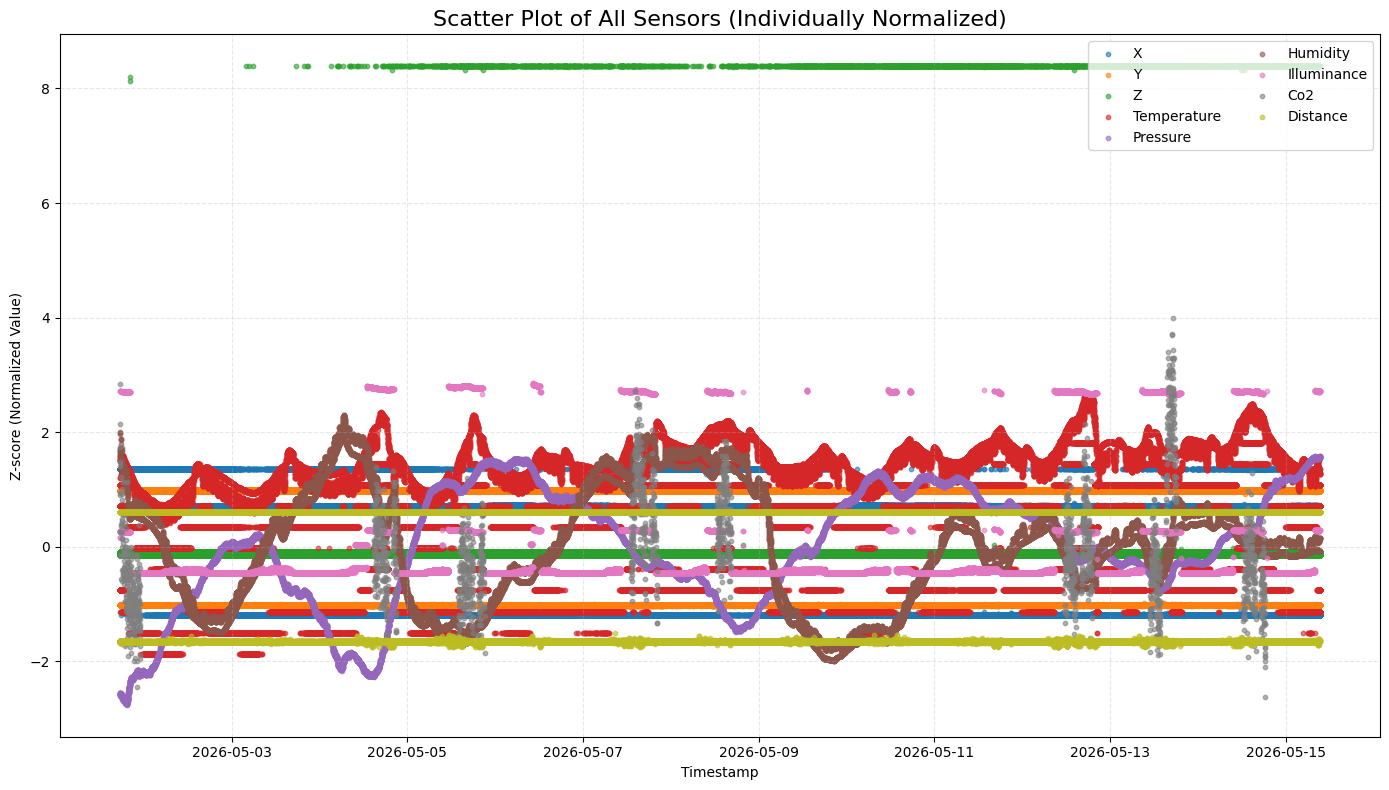

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ======================================================
# 1. Excelファイル読み込み
# ======================================================
#filename = "D:/rerf/coresearch/RSSI/WiFi_Capture/20251021/teraterm_251021_oya.xlsx"
#filename = "D:/rerf/coresearch/RSSI/WiFi_Capture/20260424/all_log_20260424.xlsx"
filename = "D:/rerf/coresearch/RSSI/WiFi_Capture/20260501/all_log_20260501.xlsx"
df = pd.read_excel(filename)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# ======================================================
# 2. 対象列の定義
# ======================================================
accel_cols = [c for c in ['X', 'Y', 'Z'] if c in df.columns]
env_cols   = [c for c in ['Temperature', 'Pressure', 'Humidity', 'Illuminance'] if c in df.columns]
co2_cols   = [c for c in ['Co2'] if c in df.columns]
dist_cols  = [c for c in ['Distance'] if c in df.columns]

all_cols = accel_cols + env_cols + co2_cols + dist_cols

# ======================================================
# 3. 各列を独立して標準化
# ======================================================
df_scaled = df.copy()
scaler = StandardScaler()

for col in all_cols:
    df_scaled[col] = scaler.fit_transform(df[[col]])

# ======================================================
# 4. DataFrameを「縦長」構造に変換（センサー列→ラベル化）
# ======================================================
df_melt = df_scaled.melt(
    id_vars='Timestamp',
    value_vars=all_cols,
    var_name='Sensor',
    value_name='NormalizedValue'
)

# ======================================================
# 5. 散布図を作成（色別センサー）
# ======================================================
plt.figure(figsize=(14, 8))

# 各センサーを色別に散布
for sensor in all_cols:
    plt.scatter(
        df_melt[df_melt['Sensor'] == sensor]['Timestamp'],
        df_melt[df_melt['Sensor'] == sensor]['NormalizedValue'],
        s=10, alpha=0.6, label=sensor
    )

plt.title('Scatter Plot of All Sensors (Individually Normalized)', fontsize=16)
plt.xlabel('Timestamp')
plt.ylabel('Z-score (Normalized Value)')
plt.legend(loc='upper right', ncol=2)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [10]:
import sys
print(sys.executable)

C:\Users\ono\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe


In [11]:
!{sys.executable} -m pip install seaborn --upgrade

In [11]:
#--------------------------------------------------------------------------------------------------
# RAG Vectorデータベースの作成
#　　10分間隔でチャンク化
#　　各センサのポーリング間隔が一定でないため，統計値で固定長ベクトルを生成
#--------------------------------------------------------------------------------------------------
from scipy.stats import linregress
import pandas as pd
import numpy as np
import faiss
import csv
import os
from glob import glob

# １０分間隔でチャンク化
CONST_TIME_FREQ = '10min'

# === センサ項目の定義 ===
all_possible_sensors = ['Distance', 'Co2', 'X', 'Y', 'Z', 'Temperature', 'Pressure', 'Humidity', 'Illuminance']
event_feature = 'EventStatus'

# === ステップ1: すべてのExcelファイル読み込み ===
#all_files = glob("D:/rerf/coresearch/RSSI/WiFi_Capture/20260424/*.xlsx")
all_files = glob("D:/rerf/coresearch/RSSI/WiFi_Capture/20260501/*.xlsx")
dataframes = []
available_sensors = set()

for file in all_files:
    df = pd.read_excel(file)
    df.columns = df.columns.str.strip()

    if 'Timestamp' not in df.columns:
        print(f"スキップ: {file} に Timestamp 列がありません")
        continue

    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df['SourceFile'] = file  # 任意

    # 存在するセンサ列を記録
    present_sensors = [col for col in all_possible_sensors + [event_feature] if col in df.columns]
    available_sensors.update(present_sensors)

    df = df[['Timestamp'] + present_sensors]
    dataframes.append(df)

# === ステップ2: 全データを統合 ===
if not dataframes:
    raise ValueError("有効なExcelファイルがありませんでした。")

combined_df = pd.concat(dataframes, ignore_index=True)
combined_df = combined_df.set_index('Timestamp').sort_index()

print(f"\n統合後総件数: {len(combined_df):,} 件")

combined_df.head()

# === 実際に利用できるセンサ列だけで処理 ===
raw_features = [f for f in all_possible_sensors if f in available_sensors]
use_event = event_feature in available_sensors

# === ステップ3: 統計特徴量抽出関数 ===
def extract_advanced_features(group):
    features = {}

    # 人感センサ
    if use_event:
        features['EventCount'] = (group[event_feature] == 4).sum()
    else:
        features['EventCount'] = 0

    for col in all_possible_sensors:  # 欠損センサにも0ベクトルを用意
        if col not in raw_features:
            # センサがこのチャンクに存在しない → 全統計量0で埋める
            stats = {k: 0 for k in [
                'mean', 'median', 'min', 'max', 'std', 'var',
                'diff_mean', 'diff_max', 'first', 'last',
                'outlier_ratio', 'zero_ratio', 'range', 'energy',
                'mean_fst_half', 'mean_lst_half', 'slope'
            ]}
        else:
            data = group[col].dropna().values
            n = len(data)

            if n == 0:
                stats = {k: 0 for k in [
                    'mean', 'median', 'min', 'max', 'std', 'var',
                    'diff_mean', 'diff_max', 'first', 'last',
                    'outlier_ratio', 'zero_ratio', 'range', 'energy',
                    'mean_fst_half', 'mean_lst_half', 'slope'
                ]}
            else:
                diff = np.diff(data)
                z_scores = (data - np.mean(data)) / (np.std(data) + 1e-8)
                half_tm = len(data) // 2
                stats = {
                    'mean': np.mean(data),
                    'median': np.median(data),
                    'min': np.min(data),
                    'max': np.max(data),
                    'std': np.std(data),
                    'var': np.var(data),
                    'diff_mean': np.mean(diff) if len(diff) > 0 else 0,
                    'diff_max': np.max(np.abs(diff)) if len(diff) > 0 else 0,
                    'first': data[0],
                    'last': data[-1],
                    'outlier_ratio': np.sum(np.abs(z_scores) > 2) / n,
                    'zero_ratio': np.sum(data == 0) / n,
                    'range': np.max(data) - np.min(data),
                    'energy': np.sum(np.square(data)),
                    # Add 3 features
                    'mean_fst_half': np.mean(data[:half_tm]) if half_tm > 0 else data[0],
                    'mean_lst_half': np.mean(data[half_tm:]) if half_tm > 0 else data[0],
                    'slope': linregress(range(len(data)), data)[0] if len(data) > 1 else 0
                }

        for stat_name, value in stats.items():
            features[f'{col}_{stat_name}'] = value

    return pd.Series(features)

# === ステップ4: チャンク処理とFAISS登録 ===
#features_df = combined_df.groupby(pd.Grouper(freq=CONST_TIME_FREQ)).apply(extract_advanced_features).dropna()
features_df = combined_df.groupby(pd.Grouper(freq=CONST_TIME_FREQ)).apply(
    extract_advanced_features
).dropna()

# 確認
print(f"features_df shape: {features_df.shape}")
print(f"features_df type: {type(features_df)}")

feature_vectors = features_df.to_numpy().astype('float32')

dimension = feature_vectors.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(feature_vectors)

# ======================
# FAISSインデックスの作成と保存
# ======================
#os.makedirs("D:/rerf/coresearch/RSSI/WiFi_Capture/20260424/rag_db", exist_ok=True)
os.makedirs("D:/rerf/coresearch/RSSI/WiFi_Capture/20260501/rag_db", exist_ok=True)

#np.save("D:/rerf/coresearch/RSSI/WiFi_Capture/20260424/rag_db/sensor_vectors_features.npy", feature_vectors)
#features_df.to_csv("D:/rerf/coresearch/RSSI/WiFi_Capture/20260424/rag_db/sensor_feature_vectors.csv")
#faiss.write_index(index, "D:/rerf/coresearch/RSSI/WiFi_Capture/20260424/rag_db/sensor_faiss_features.index")

np.save("D:/rerf/coresearch/RSSI/WiFi_Capture/20260501/rag_db/sensor_vectors_features.npy", feature_vectors)
features_df.to_csv("D:/rerf/coresearch/RSSI/WiFi_Capture/20260501/rag_db/sensor_feature_vectors.csv")
faiss.write_index(index, "D:/rerf/coresearch/RSSI/WiFi_Capture/20260501/rag_db/sensor_faiss_features.index")

# ======================
# HNSWインデックスの作成と保存
# ======================
d = feature_vectors.shape[1]  # 次元数（127）
M = 32                      # グラフの近傍数
index = faiss.IndexHNSWFlat(d, M)
index.hnsw.efConstruction = 200
index.add(feature_vectors)

#faiss.write_index(index, "D:/rerf/coresearch/RSSI/WiFi_Capture/20260424/rag_db/sensor_HNSW_features.index")
faiss.write_index(index, "D:/rerf/coresearch/RSSI/WiFi_Capture/20260501/rag_db/sensor_HNSW_features.index")

feature_names = features_df.columns.tolist()
with open("D:/rerf/coresearch/RSSI/WiFi_Capture/20260501/rag_db/sensor_features_NM.csv", "w", encoding="utf_8", newline="") as f:
#with open("D:/rerf/coresearch/RSSI/WiFi_Capture/20260424/rag_db/sensor_features_NM.csv", "w", encoding="utf_8", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(feature_names)
    
print("処理完了: ファイル数 =", len(all_files))
print("ベクトル数 =", feature_vectors.shape[0], "次元 =", feature_vectors.shape[1])



統合後総件数: 830,196 件
features_df shape: (1969, 154)
features_df type: <class 'pandas.core.frame.DataFrame'>
処理完了: ファイル数 = 1
ベクトル数 = 1969 次元 = 154


読み込んだベクトル数: 1969, 次元数: 154
k=2: Silhouette Score = 0.5719
k=3: Silhouette Score = 0.5791
k=4: Silhouette Score = 0.5575
k=5: Silhouette Score = 0.5397
k=6: Silhouette Score = 0.5458
k=7: Silhouette Score = 0.5403
k=8: Silhouette Score = 0.5203
k=9: Silhouette Score = 0.5337
k=10: Silhouette Score = 0.5272
k=11: Silhouette Score = 0.5339
k=12: Silhouette Score = 0.5377
k=13: Silhouette Score = 0.5365
k=14: Silhouette Score = 0.5352
k=15: Silhouette Score = 0.5257
k=16: Silhouette Score = 0.5128
k=17: Silhouette Score = 0.5175
k=18: Silhouette Score = 0.5164
k=19: Silhouette Score = 0.5157


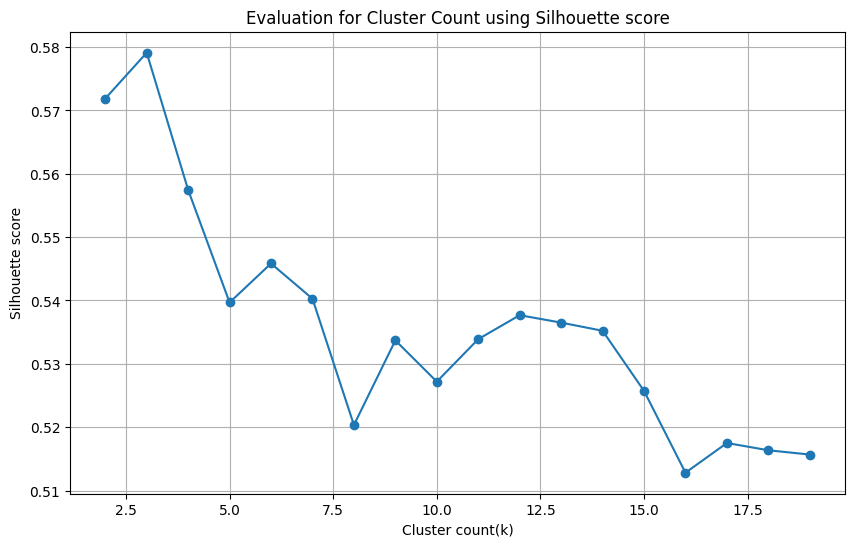

最も良いクラスタ数（シルエットスコア最大）: k = 3


In [12]:
import faiss
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ======================
# 1. ベクトルデータ読み込み（faiss）
# ======================
#index = faiss.read_index("D:/rerf/coresearch/RSSI/WiFi_Capture/20260424/rag_db/sensor_faiss_features.index")
index = faiss.read_index("D:/rerf/coresearch/RSSI/WiFi_Capture/20260501/rag_db/sensor_faiss_features.index")
vectors = np.vstack([index.reconstruct(i) for i in range(index.ntotal)])

print(f"読み込んだベクトル数: {vectors.shape[0]}, 次元数: {vectors.shape[1]}")

# ======================
# 2. クラスタ数の最適化（シルエット法）
# ======================
range_k = range(2, 20)
silhouette_scores = []

for k in range_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto').fit(vectors)
    score = silhouette_score(vectors, kmeans.labels_)
    print(f"k={k}: Silhouette Score = {score:.4f}")
    silhouette_scores.append(score)

# シルエットスコアの可視化
plt.figure(figsize=(10, 6))
plt.plot(range_k, silhouette_scores, marker='o')
plt.title("Evaluation for Cluster Count using Silhouette score")
plt.xlabel("Cluster count(k)")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.savefig("D:/rerf/coresearch/RSSI/WiFi_Capture/20260501/rag_db/silhouette_score.png") 
plt.show()

# ======================
# 3. 最適クラスタ数でクラスタリング実行
# ======================
best_k = range_k[np.argmax(silhouette_scores)]
print(f"最も良いクラスタ数（シルエットスコア最大）: k = {best_k}")

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init='auto').fit(vectors)
cluster_labels = kmeans_final.labels_


読み込んだベクトル数: 1969, 次元数: 154
k=2: Silhouette Score = 0.5719
k=3: Silhouette Score = 0.5791
k=4: Silhouette Score = 0.5575
k=5: Silhouette Score = 0.5397
k=6: Silhouette Score = 0.5458
k=7: Silhouette Score = 0.5403
k=8: Silhouette Score = 0.5203
k=9: Silhouette Score = 0.5337
k=10: Silhouette Score = 0.5272
k=11: Silhouette Score = 0.5339
k=12: Silhouette Score = 0.5377
k=13: Silhouette Score = 0.5365
k=14: Silhouette Score = 0.5352
k=15: Silhouette Score = 0.5257
k=16: Silhouette Score = 0.5128
k=17: Silhouette Score = 0.5175
k=18: Silhouette Score = 0.5164
k=19: Silhouette Score = 0.5157


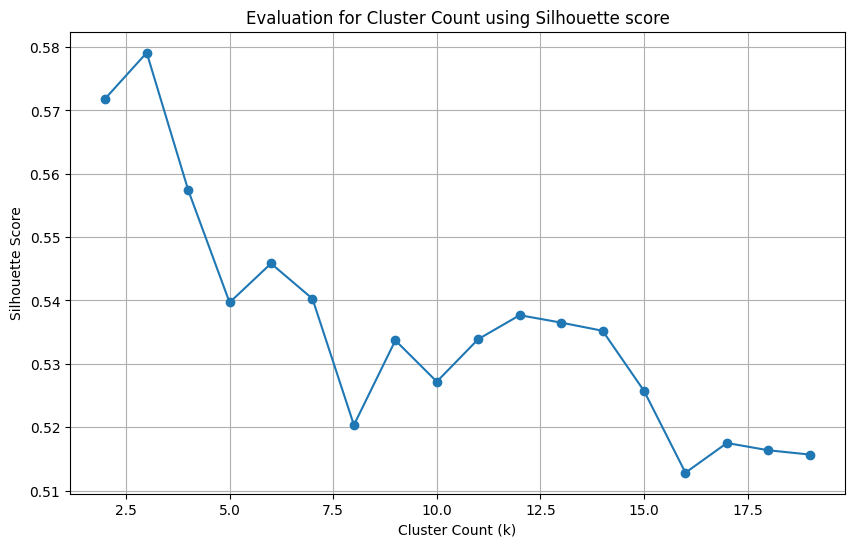

最も良いクラスタ数（シルエットスコア最大）: k = 3


In [13]:
import faiss
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ======================
# 1. ベクトルデータ読み込み（HNSW）
# ======================
#index = faiss.read_index("D:/rerf/coresearch/RSSI/WiFi_Capture/20260424/rag_db/sensor_HNSW_features.index")
index = faiss.read_index("D:/rerf/coresearch/RSSI/WiFi_Capture/20260501/rag_db/sensor_HNSW_features.index")
vectors = np.vstack([index.reconstruct(i) for i in range(index.ntotal)])

print(f"読み込んだベクトル数: {vectors.shape[0]}, 次元数: {vectors.shape[1]}")

# ======================
# 2. クラスタ数の最適化（シルエット法）
# ======================
range_k = range(2, 20)
silhouette_scores = []

for k in range_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto').fit(vectors)
    score = silhouette_score(vectors, kmeans.labels_)
    print(f"k={k}: Silhouette Score = {score:.4f}")
    silhouette_scores.append(score)

# シルエットスコアの可視化
plt.figure(figsize=(10, 6))
plt.plot(range_k, silhouette_scores, marker='o')
plt.title("Evaluation for Cluster Count using Silhouette score")
plt.xlabel("Cluster Count (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

# ======================
# 3. 最適クラスタ数でクラスタリング実行
# ======================
best_k = range_k[np.argmax(silhouette_scores)]
print(f"最も良いクラスタ数（シルエットスコア最大）: k = {best_k}")

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init='auto').fit(vectors)
cluster_labels = kmeans_final.labels_


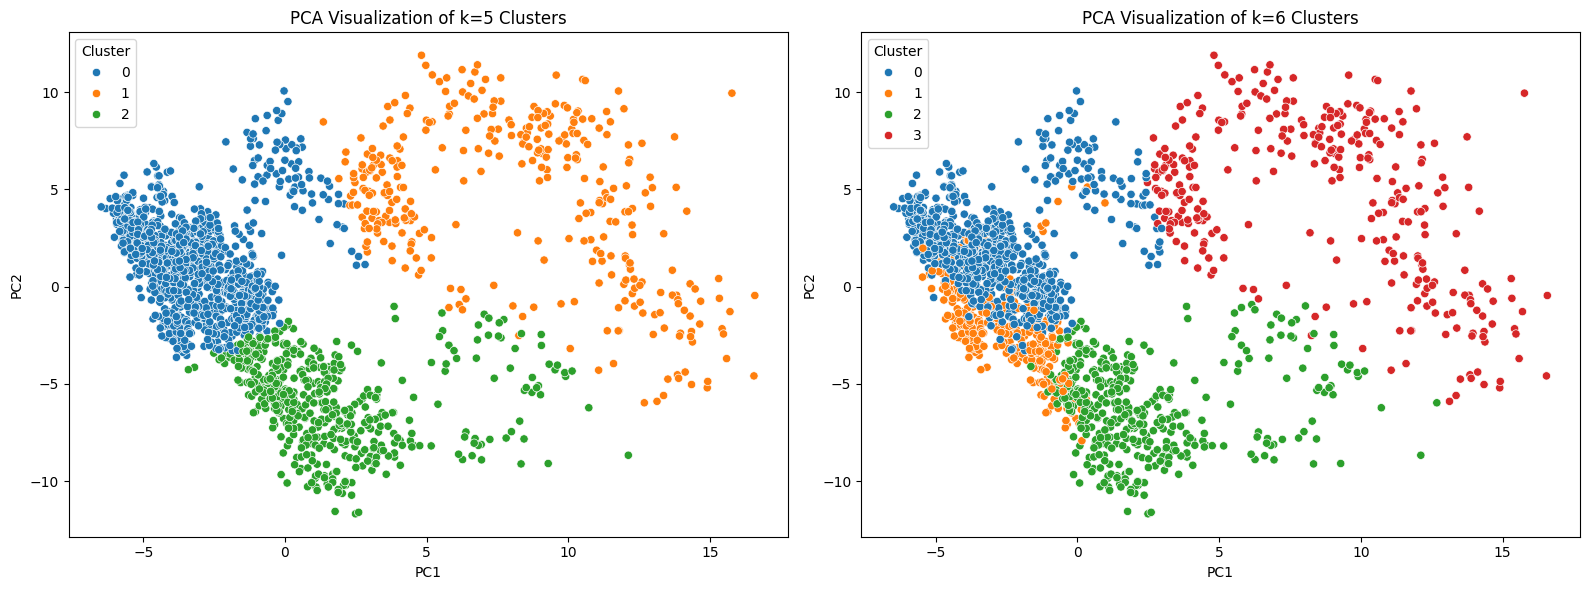

In [14]:
import numpy as np
import faiss
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ======================
# 1. ベクトルデータの読み込み
# ======================

# ② .index から直接読み込みたい場合（IndexFlatL2のみ対応）
#index = faiss.read_index("D:/rerf/coresearch/RSSI/WiFi_Capture/20260424/rag_db/sensor_faiss_features.index")
index = faiss.read_index("D:/rerf/coresearch/RSSI/WiFi_Capture/20260501/rag_db/sensor_faiss_features.index")
vectors = np.vstack([index.reconstruct(i) for i in range(index.ntotal)])

# ======================
# 2. スケーリング
# ======================
scaler = StandardScaler()
vectors_scaled = scaler.fit_transform(vectors)

# ======================
# 3. k-meansクラスタリング（k=5, k=6）
# ======================
kmeans_5 = KMeans(n_clusters=3, random_state=42)
labels_k5 = kmeans_5.fit_predict(vectors_scaled)
np.save("D:/rerf/coresearch/RSSI/WiFi_Capture/20260501/rag_db/cluster_labels_k5.npy", labels_k5)

kmeans_6 = KMeans(n_clusters=4, random_state=42)
labels_k6 = kmeans_6.fit_predict(vectors_scaled)
np.save("D:/rerf/coresearch/RSSI/WiFi_Capture/20260501/rag_db/cluster_labels_k6.npy", labels_k6)

# ======================
# 3. PCAで2次元に次元圧縮（可視化用）
# ======================
pca = PCA(n_components=2, random_state=42)
vectors_pca = pca.fit_transform(vectors_scaled)

# ======================
# 5. プロット用データ整形
# ======================
df = pd.DataFrame(vectors_pca, columns=["PC1", "PC2"])
df["Cluster_k5"] = labels_k5
df["Cluster_k6"] = labels_k6

# ======================
# 6. クラスタ可視化
# ======================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df, x="PC1", y="PC2", hue="Cluster_k5", palette="tab10", ax=axes[0])
axes[0].set_title("PCA Visualization of k=5 Clusters")
axes[0].legend(title="Cluster")

sns.scatterplot(data=df, x="PC1", y="PC2", hue="Cluster_k6", palette="tab10", ax=axes[1])
axes[1].set_title("PCA Visualization of k=6 Clusters")
axes[1].legend(title="Cluster")

plt.tight_layout()
plt.savefig("D:/rerf/coresearch/RSSI/WiFi_Capture/20260501/rag_db/PCI_Analysis.png") 
plt.show()


In [15]:
import shap
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tqdm import tqdm

# NumPy の互換性対応（SHAP エラー回避）
if not hasattr(np, "bool8"):
    np.bool8 = np.bool_

# 特徴ベクトルとクラスタラベルの読み込み
X = np.load("D:/rerf/coresearch/RSSI/WiFi_Capture/20260501/rag_db/sensor_vectors_features.npy")
y = np.load("D:/rerf/coresearch/RSSI/WiFi_Capture/20260501/rag_db/cluster_labels_k5.npy")

# スケーリング（念のため）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 学習・テストデータ分割
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)



C:\Users\ono\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
X

array([[0.       , 0.       , 0.       , ..., 0.9825233, 0.9653521,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.9793847, 0.9591945,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.9951791, 0.9903815,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 1.0161617, 1.0325847,
        0.       ],
       [0.       , 0.       , 0.       , ..., 1.0144736, 1.0291566,
        0.       ],
       [0.       , 0.       , 0.       , ..., 1.0183551, 1.0370473,
        0.       ]], shape=(525, 151), dtype=float32)

  0%|                                                                                            | 0/3 [00:00<?, ?it/s]

Cluster 0のSHAPプロット


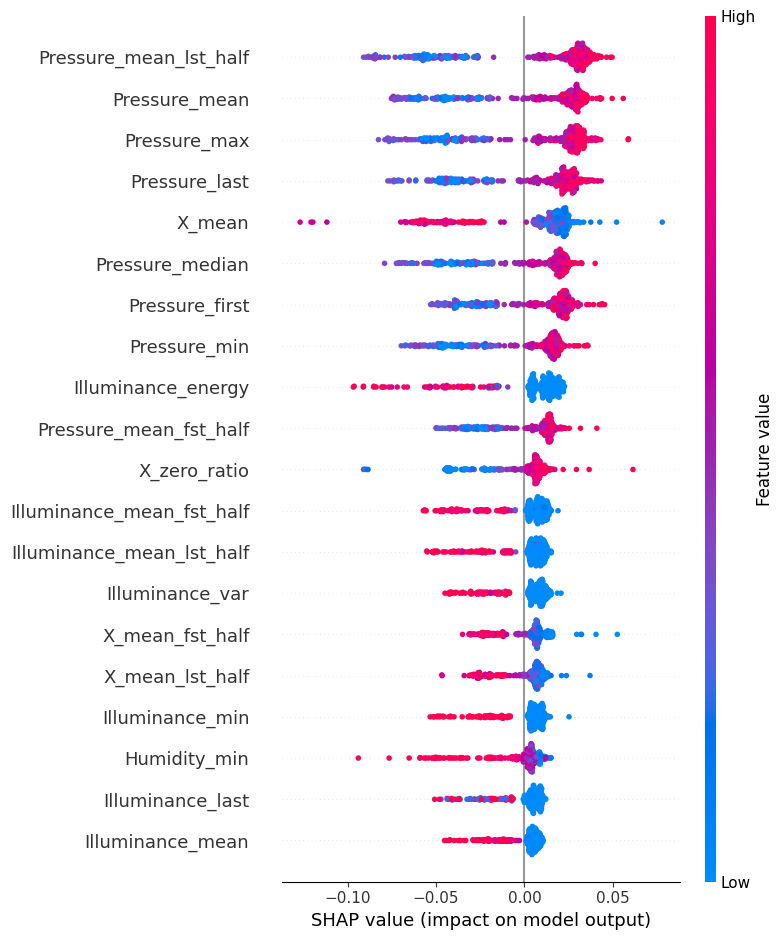

 33%|████████████████████████████                                                        | 1/3 [00:00<00:01,  1.66it/s]

Cluster 1のSHAPプロット


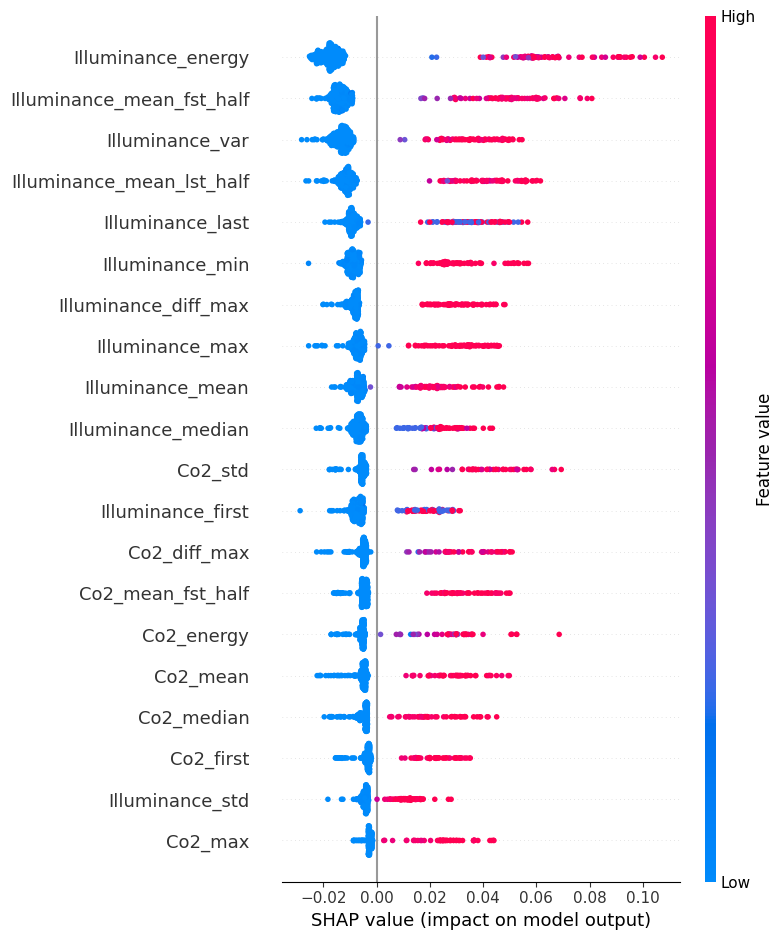

 67%|████████████████████████████████████████████████████████                            | 2/3 [00:01<00:00,  1.69it/s]

Cluster 2のSHAPプロット


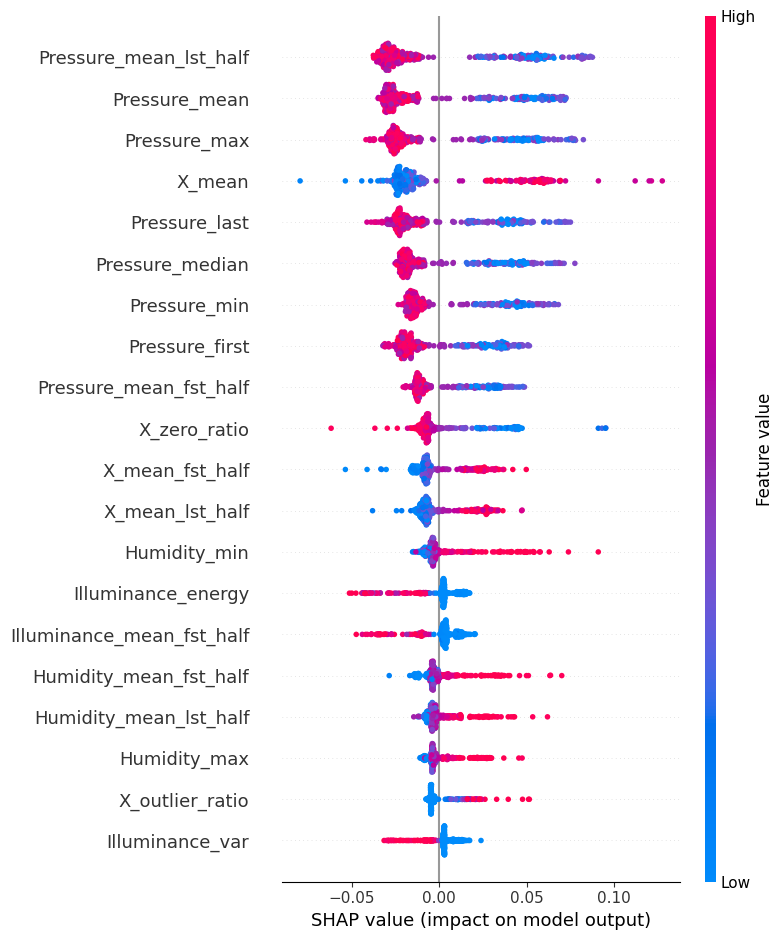

100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  1.69it/s]


In [16]:
X_test_df = pd.DataFrame(X_test, columns=feature_names)

# ランダムフォレストモデルの訓練
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# SHAPのTreeExplainerを使った特徴量重要度の計算
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap_array = np.array(shap_values)    

for class_idx in tqdm(range(shap_array.shape[2])):
    print(f"Cluster {class_idx}のSHAPプロット")
    shap.summary_plot(
        shap_array[:,:,class_idx],
        X_test,
        feature_names=feature_names,
        show=True
    )

In [8]:
all_cols = pd.read_csv('D:/rerf/coresearch/RSSI/WiFi_Capture/20251021/rag_db/sensor_features_NM.csv', nrows=0).columns.tolist()
print(len(all_cols))    # 何列あるか
print(all_cols[:3]) 

154
['Co2_diff_max', 'Co2_diff_mean', 'Co2_energy']


In [7]:
features_df_raw = combined_df.groupby(pd.Grouper(freq=CONST_TIME_FREQ)).apply(extract_advanced_features)
print(features_df_raw.shape)
print(features_df_raw.head())
print(features_df_raw.isnull().sum().sum())  # NaNの総数

(28032,)
Timestamp                           
2025-10-21 09:10:00  EventCount            34.000000
                     Distance_mean      13737.601351
                     Distance_median     2313.000000
                     Distance_min         681.000000
                     Distance_max       30007.000000
dtype: float64
0


In [9]:
print(features_df.shape)  # (次元数は127+(3*9)=154) になるはず
print(features_df.head())

(98, 154)
                     Co2_diff_max  Co2_diff_mean  Co2_energy  Co2_first  \
Timestamp                                                                 
2025-10-21 09:10:00          63.0       1.875000   3016663.0      392.0   
2025-10-21 09:20:00         138.0       4.117647   3233201.0      406.0   
2025-10-21 09:30:00         122.0      -0.769231   2357763.0      394.0   
2025-10-21 09:40:00         155.0       2.312500   3009696.0      401.0   
2025-10-21 09:50:00         138.0       6.666667   2334738.0      441.0   

                     Co2_last  Co2_max    Co2_mean  Co2_mean_fst_half  \
Timestamp                                                               
2025-10-21 09:10:00     422.0    463.0  420.529412         420.000000   
2025-10-21 09:20:00     476.0    525.0  421.611111         420.000000   
2025-10-21 09:30:00     384.0    512.0  407.642857         429.571429   
2025-10-21 09:40:00     438.0    527.0  418.235294         405.500000   
2025-10-21 09:50:00     52